# 13-Instruction Tuning (SFT)

Over the past two lessons, we learned *how* to fine-tune a massive LLM using LoRA and 4-bit Quantization (QLoRA). But a massive question remains: **What exact data are we feeding into the network, and how do we calculate the loss?**

If you take a Base Model (like `Llama-3-70B-Base`) and prompt it with: *"What is the capital of France?"*, it will likely respond with *"What is the capital of Germany? What is the capital of Italy?"* Why? Because a Base Model is just a **Document Continuer**. It has read millions of web pages containing lists of trivia questions, so it mathematically assumes you just want to generate more questions.

To transform a Base Model into ChatGPT, we must perform **Supervised Fine-Tuning (SFT)** on heavily structured dialogue. We call this **Instruction Tuning**.

Let's set up our PyTorch environment to master the engineering of conversational formatting and Loss Masking.


In [1]:
import torch
import torch.nn as nn
from transformers import GPT2Tokenizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Instruction Tuning Environment Ready.")

✅ PyTorch Instruction Tuning Environment Ready.


# 1. The Anatomy of a Prompt Template

To teach a model that it is having a conversation, we cannot just feed it raw text. We must inject strict, unalterable mathematical boundary markers into the text. These markers tell the network exactly when a human is speaking, and exactly when the AI is expected to respond.

Every major AI company uses a different template. One of the most famous and structurally sound is OpenAI's **ChatML** format. It uses special control tokens like `<|im_start|>` and `<|im_end|>`.

A raw training data example looks like this:

```text
<|im_start|>system
You are a helpful AI physics tutor.<|im_end|>
<|im_start|>user
What is gravity?<|im_end|>
<|im_start|>assistant
Gravity is a fundamental force of nature.<|im_end|>

```

During SFT, we feed thousands of these perfectly formatted transcripts into the network so it mathematically memorizes the rhythm of the conversation.

# 2. The Fatal Flaw: Training on the Prompt

Here is where 90% of junior machine learning engineers fail.

Standard Next-Token Prediction (which we built in Lesson 08) calculates the Cross-Entropy Loss for *every single token* in the sequence.
If we feed the ChatML transcript above into a standard training loop, the network will calculate a loss for predicting the word "What", the word "is", and the word "gravity?".

**This is catastrophic.** You are mathematically penalizing the AI for failing to predict what the *User* is going to ask! If you train an LLM on the User's prompt, the AI will slowly rewrite its internal weights to sound like a human user. It will start generating typos, asking questions, and hallucinating user personas.

# 3. The Mathematics of Loss Masking (`-100`)

We must calculate the gradients **ONLY on the Assistant's response**.

To do this, we use PyTorch's `ignore_index` mechanism inside `nn.CrossEntropyLoss`. By default, this index is set to exactly **`-100`**.

We create a **Label Tensor** that is perfectly aligned with our Input Tokens.

1. We copy the Input Tokens into the Label Tensor.
2. We write a Python script to find the exact index where `<|im_start|>user` begins, and where `<|im_start|>assistant` ends.
3. We overwrite all the user and system tokens in the Label Tensor with `-100`.

$$\mathcal{L}_{SFT} = -\sum_{t=1}^{T} \begin{cases} 
0 & \text{if label}_t = -100 \\
\log P(x_t | x_{<t}) & \text{otherwise}
\end{cases}$$

During Backpropagation, when PyTorch sees `-100`, the gradient for that specific token is mathematically multiplied by $0.0$. The model reads the user's prompt to gain context (Forward Pass), but it only *learns* how to generate the Assistant's response (Backward Pass).

# 4. Engineering the Label Mask in PyTorch

Let's write the exact enterprise data-collator logic used to format a ChatML dialogue and construct the `-100` Loss Mask. We will use a standard tokenizer and manually step through the sequence to protect the user's prompt.

--- 📥 Initializing Tokenizer & Control Tokens ---
--- 📝 The Full Training Sequence ---
<|system|>
You are a tutor.<|end|>
<|user|>
What is a Quasar?<|end|>
<|assistant|>
A quasar is a highly active galactic nucleus.<|end|>

--- 🛡️ Constructing the Loss Mask ---
Error: Could not find assistant tag.

--- 🧮 Tensor Alignment Table ---
 Step     Token  Input ID (Forward Pass)  Label ID (Backward Pass)
    0         <                       27                        27
    1         |                       91                        91
    2    system                    10057                     10057
    3         |                       91                        91
    4         >                       29                        29
    5        \n                      198                       198
    6       You                     1639                      1639
    7       are                      389                       389
    8         a                      257                       2

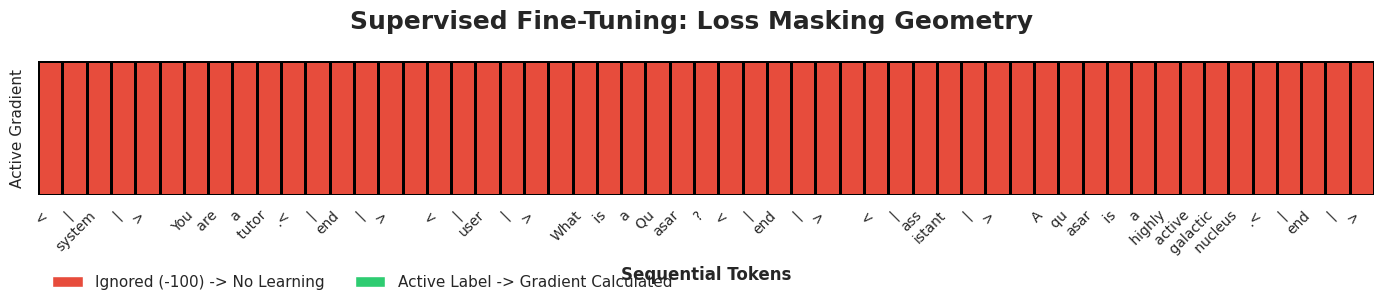


--- 💡 Engineering Insight ---
Look at the Red Zone. During the Forward Pass, the model reads the User's prompt. It is absolutely critical that the model SEES these tokens so it can build the Self-Attention matrix and understand the question. However, during the Backward Pass, the Red Zone generates exactly 0.0 loss. The model's weights are NOT updated to predict these words.
Look at the Green Zone. The moment the `<|assistant|>` token ends, the labels switch from -100 back to the actual token IDs. The network now calculates Cross-Entropy Loss on predicting 'A', 'quas', 'ar', etc. It learns to perfectly emulate the tone, factual accuracy, and style of the Assistant without ever corrupting its brain by trying to emulate the User.


In [2]:
# 1. Initialize the Tokenizer
print("--- 📥 Initializing Tokenizer & Control Tokens ---")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")

# In a real model, these are added as special vocabulary tokens.
# For this simulation, we will define them clearly in text.
system_prompt = "<|system|>\nYou are a tutor.<|end|>\n"
user_prompt = "<|user|>\nWhat is a Quasar?<|end|>\n"
assistant_response = "<|assistant|>\nA quasar is a highly active galactic nucleus.<|end|>"

# 2. Construct the Full Sequence
full_text = system_prompt + user_prompt + assistant_response
print("--- 📝 The Full Training Sequence ---")
print(full_text)

# Tokenize the full sequence
input_ids = tokenizer.encode(full_text, return_tensors="pt")[0]
tokens = [tokenizer.decode([t]) for t in input_ids]
seq_len = len(input_ids)

# 3. Architecting the Label Mask
print("\n--- 🛡️ Constructing the Loss Mask ---")
# Clone the input IDs to create our baseline labels
labels = input_ids.clone()

# Find the exact boundaries (In production, this is done by finding specific token IDs)
# Here, we will find the indices by matching the text
assistant_start_idx = None
for i in range(seq_len - 2):
    # Search for the "< | assistant | > \n" token sequence combination
    decoded_slice = tokenizer.decode(input_ids[i:i+3]).replace(" ", "")
    if "<|assistant|>" in decoded_slice:
        assistant_start_idx = i + 3 # Start learning AFTER the assistant tag
        break

# The Mathematical Masking Step
# Overwrite everything before the assistant's response with -100
if assistant_start_idx is not None:
    labels[:assistant_start_idx] = -100
    print(f"Success: Masked tokens 0 through {assistant_start_idx-1} with -100.")
else:
    print("Error: Could not find assistant tag.")

# 4. Visualizing the Tensors
# Let's put this in a clean Pandas DataFrame to see exactly what the model and the Loss Function see
df = pd.DataFrame({
    "Step": np.arange(seq_len),
    "Token": tokens,
    "Input ID (Forward Pass)": input_ids.numpy(),
    "Label ID (Backward Pass)": labels.numpy()
})

print("\n--- 🧮 Tensor Alignment Table ---")
print(df.to_string(index=False))

# 5. Visualizing the Gradient Physics
fig, ax = plt.subplots(figsize=(14, 4))
fig.suptitle("Supervised Fine-Tuning: Loss Masking Geometry", fontsize=18, fontweight='bold')

# Create an array of 0s and 1s for the heatmap (0 for masked, 1 for active)
# Shape: [1, seq_len]
active_loss_grid = (labels != -100).numpy().astype(int).reshape(1, -1)

# Plot the mask
sns.heatmap(active_loss_grid, 
            xticklabels=tokens, 
            yticklabels=["Active Gradient"],
            cmap=["#e74c3c", "#2ecc71"], # Red for masked, Green for active
            cbar=False,
            linewidths=1,
            linecolor='black',
            ax=ax)

ax.set_xlabel("Sequential Tokens", fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)

# Add a custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Ignored (-100) -> No Learning'),
                   Patch(facecolor='#2ecc71', label='Active Label -> Gradient Calculated')]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, -0.5), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Red Zone. During the Forward Pass, the model reads the User's prompt. It is absolutely critical that the model SEES these tokens so it can build the Self-Attention matrix and understand the question. However, during the Backward Pass, the Red Zone generates exactly 0.0 loss. The model's weights are NOT updated to predict these words.")
print("Look at the Green Zone. The moment the `<|assistant|>` token ends, the labels switch from -100 back to the actual token IDs. The network now calculates Cross-Entropy Loss on predicting 'A', 'quas', 'ar', etc. It learns to perfectly emulate the tone, factual accuracy, and style of the Assistant without ever corrupting its brain by trying to emulate the User.")

## Real-World Use Case or Analogy:

Think of Instruction Tuning like **Training an Actor for a Play**:

* **The Pre-Trained Base Model (The Improv Comedian)**: You hire a brilliant improv comedian. If another actor walks on stage and says, *"Hello, where is the library?"*, the improv comedian might respond, *"I don't know, where is the kitchen?!"* They are just riffing and keeping the conversation going. They are smart, but uncontrollable.
* **Supervised Fine-Tuning (The Script)**: You hand the comedian a strict script (The Dataset).
* **Training on the Prompt (The Catastrophic Error)**: You tell the comedian, *"Memorize everything in this script."* The comedian memorizes *both* roles. When the other actor says, *"Hello, where is the library?"*, the comedian replies by reading the stage directions: *"(User walks in) Hello, where is the library?"* They have completely ruined the play because they learned the wrong part of the sequence.
* **Loss Masking (`-100`)**: You take a thick black Sharpie and cross out the other actor's lines in the script. You tell the comedian, *"You must LISTEN to the crossed-out lines so you know when to speak, but you must only MEMORIZE your own lines."* The comedian perfectly learns their role.